# product2 머신러닝 (확인용)

In [3]:
# 라이브러리 import
import pandas as pd
import numpy as np
import platform
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report, average_precision_score, PrecisionRecallDisplay)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns

import shap
import matplotlib.pyplot as plt


import joblib
import os

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 고정
np.random.seed(42)

### 1. 데이터 로드

In [4]:
# 데이터 로드
df = pd.read_csv("../Data/ML_modeling_data_product-2.csv")
df.head()

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0
1,4208012_12,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
3,4210014_14,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
4,4211015_15,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0


--- 

0 -> 정상 <br>
1 -> 불량

In [5]:
# 타겟(y) 컬럼과 제외할 컬럼 정의
target_cols = "is_defect"
drop_cols = [
    target_cols,
    "spray_1_time",
    "rapid_rise_time",
    "factory_humidity",
    "air_pressure",
    "velocity_1",
    "biscuit_thickness",
    "shot_key"
]

# X/y 분리
X = df.drop(columns=drop_cols) # feature
y = df[target_cols] # target

print(X.shape)
print(y.value_counts())

(3328, 14)
is_defect
0    2382
1     946
Name: count, dtype: int64


--- 

### 2. Train / Test 데이터 분리 및 저장

기본 조건
- train: test = 8:2
- seed=42
- random_state = 42
- stratify = y
- shuffle = True

In [6]:
# train/test 분리 (prod1과 prod2 서로 맞춤)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

print("train shape:", X_train.shape)
print("test shape:", X_test.shape)

train shape: (2662, 14)
test shape: (666, 14)


In [7]:
# csv 형식으로 Train/Test 데이터 저장
df_train = pd.concat([X_train, y_train], axis=1) # aixs=1 : 컬럼을 기준으로 병합
df_test  = pd.concat([X_test,  y_test],  axis=1)

df_train.to_csv('../data/train_data_product-2.csv', index=False)
df_test.to_csv('../data/test_data_product-2.csv',   index=False)

print("Train Data 저장 완료")
print("Test Data 저장 완료")

Train Data 저장 완료
Test Data 저장 완료


---

### 3. 불균형 보정 / cv 파라미터 지정 / 함수 정의
- 불량률 약 2.7%으로 편향되어 소수를 탐지 할 수 없기 때문에 불규형 보정을 함
- 찾아보니 XGBoost, LightGBM 둘 다 scale_pos_weight를 사용
- scale_pos_weight: 이진 분류 문제에서 클래스 불균형 해결.
  - 소수(불량 1)에 가중치 부여하여 소수를 중요하게 학습

#### 3.1 불균형 보정

In [8]:
# 불균형 확인
print(f"샘플수 확인 (0:정상 / 1:불량): {y_train.value_counts()} \n")
pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # scale_pos_weight 계산 (전체 음성 데이터 수 / 전체 양성 데이터 수)
print("scale_pos_weight:", pos_weight)

샘플수 확인 (0:정상 / 1:불량): is_defect
0    1905
1     757
Name: count, dtype: int64 

scale_pos_weight: 2.516512549537649


#### 3.2 Stratified K-Fold 설정
- 교차검증 설정
- 불균형 분포를 가진 데이터 비율을 맞추기 위해 지정


In [9]:
# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,       # 기본적으로 5로 지정
    shuffle=True,  
    random_state=42  
)

#### 3.3 모델의 성능 평가 함수 정의

In [10]:
def evaluate_model(model, X_test, y_test, graph_title):
    
    # 1. 예측
    y_pred = model.predict(X_test) # 클래스 예측 (0 또는 1) - 확률이 0.5 이상일 때 불량으로 예측
    y_prob = model.predict_proba(X_test)[:, 1] # 불량(1)일 확률만 출력

    # 2. PR-AUC(곡선 아래 면적) 계산
    pr_auc   = average_precision_score(y_test, y_prob) # PR-AUC 곡선 아래 면적 계산
    baseline = y_test.mean() # 테스트 데이터의 불량률 -> PR-AUC 곡선의 기준선

    # 3. Precision / Recall / F1-Score 출력
    print(f"\n{'=' * 55}")
    print(f"  {graph_title}")
    print(f"{'=' * 55}")
    print(f"\nPR-AUC: {pr_auc:.4f}   (Random Baseline: {baseline:.4f})")
    print(f"\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=["정상(0)", "불량(1)"]))

    # 4. 시각화
    # fig는 안 쓸거라서 _로 처리
    # facecolor='none'의 의미: 배경을 투명하게 
    _, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='none') 

    # 5. 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=["정상(0)", "불량(1)"],
        yticklabels=["정상(0)", "불량(1)"],
        annot_kws={"size": 16}
    )
    # 5-1. 각 셀에 TN / FP / FN(위험) / TP 표시
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            axes[0].text(j + 0.5, i + 0.78, cell_labels[i][j],
                        ha="center", va="center",
                        color="gray", fontsize=9)
    axes[0].set_title(f"{graph_title}\nConfusion Matrix", fontsize=13)
    axes[0].set_ylabel("실제값", fontsize=11)
    axes[0].set_xlabel("예측값", fontsize=11)

    # 6. PR Curve
    disp = PrecisionRecallDisplay.from_predictions(
    y_test, y_prob,
    name=f"{graph_title} (PR-AUC = {pr_auc:.4f})",
    ax=axes[1],
    color="steelblue"
    )
    # 자동으로 표시되는 Average Precision(AP)를 덮어씌워서 숨김
    disp.line_.set_label(f"{graph_title} (PR-AUC = {pr_auc:.4f})")

    # 6-1. PR Curve 기준선 
    axes[1].axhline(
        y=baseline, color="gray", linestyle="--", linewidth=1.2,
        label=f"Random Baseline ({baseline:.4f})"
    )
    axes[1].set_title(f"{graph_title}\nPR Curve", fontsize=13)
    axes[1].legend(
    fontsize=10,
    bbox_to_anchor=(0.5, -0.15),  # 그래프 아래쪽으로 범례 이동
    loc='upper center',            # 기준점 설정
    ncol=1                         # 범례를 1열로 표시
    )

    plt.tight_layout()
    plt.show()

--- 

### 4. XGBoost

#### 4.1 XGBoost - 기초

In [11]:
# XGBoost
xgb_model = XGBClassifier(
    learning_rate=0.1,              # learning_rate = 0.1 공통 정해둔 것
    scale_pos_weight=pos_weight,    # 불균형 보정
    random_state=42,                # 재현성
    eval_metric="logloss",          # 내부 평가 기준 (이진 불류 표준)
    n_jobs=-1                       # 모든 CPU 코어 사용
)

In [12]:
# XGBoost 기초 성능
print("=== XGBoost 기초 성능 === \n")

xgb_model.fit(X_train, y_train)

y_pred_base = xgb_model.predict(X_test)  # 클래스 예측
y_prob_base = xgb_model.predict_proba(X_test)[:,1]  # 불량(1)일 확률

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_base))

print("Classification Report") 
print(classification_report(y_test, y_pred_base, target_names=["정상(0)", "불량(1)"]))

pr_auc_base = average_precision_score(y_test, y_prob_base)
print("PR-AUC:", pr_auc_base)

=== XGBoost 기초 성능 === 

Confusion Matrix
[[386  91]
 [ 30 159]]
Classification Report
              precision    recall  f1-score   support

       정상(0)       0.93      0.81      0.86       477
       불량(1)       0.64      0.84      0.72       189

    accuracy                           0.82       666
   macro avg       0.78      0.83      0.79       666
weighted avg       0.85      0.82      0.82       666

PR-AUC: 0.794671475390602



  XGBoost 기초 모델링 - Product 2

PR-AUC: 0.7947   (Random Baseline: 0.2838)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.93      0.81      0.86       477
       불량(1)       0.64      0.84      0.72       189

    accuracy                           0.82       666
   macro avg       0.78      0.83      0.79       666
weighted avg       0.85      0.82      0.82       666



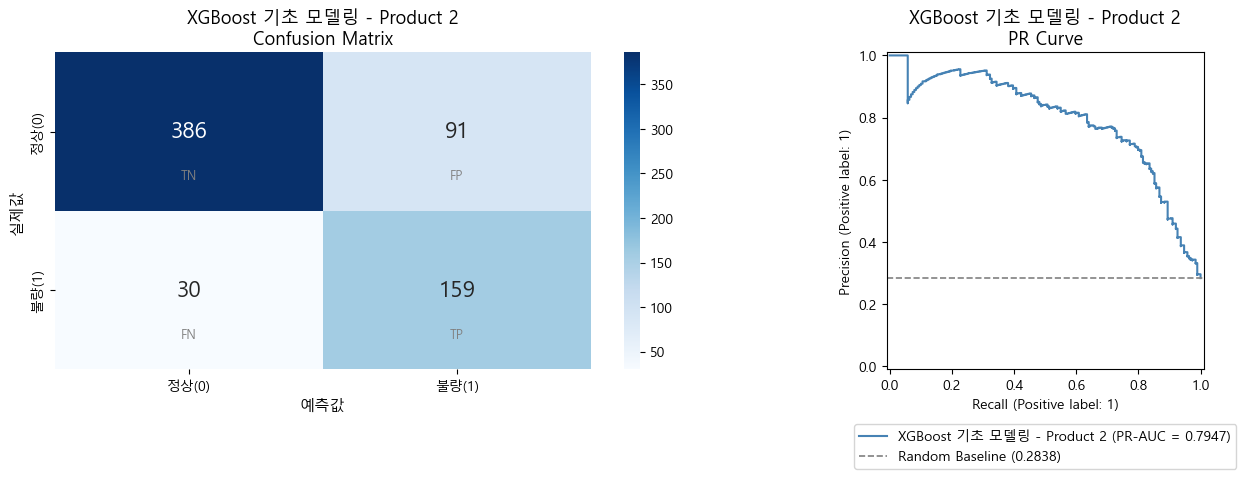

In [ ]:
# 1. XGBoost 기초 성능 평가
evaluate_model(xgb_model,  X_test, y_test, "XGBoost 기초 모델 - Product 2")

#### 4.2 XGBoost - 개선
- GridSearch 최적의 파라미터로 성능 개선

In [15]:
# XGBoost GridSearch
param_grid_xgb = {
    "n_estimators"      : [100,300,500],
    "max_depth"         : [3,5,7],
    "learning_rate"     : [0.05,0.1],
    "subsample"         : [0.8,1.0], # 전체(1.0) 데이터 중 0.8만 사용 (과적합 방지)
    "colsample_bytree"  : [0.8,1.0], # 전체(1.0) feature 중 0.8만 사용 (성능 증가)
    "min_child_weight"  : [1, 3, 5]  # 리프 노드에 최소 몇 개의 샘플이 있어야 하는가?
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=pos_weight,
        eval_metric="logloss", 
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_xgb,
    scoring="average_precision",   # 최적화
    cv=cv,              # Stratified K-Fold (공통 정해둔 것)
    n_jobs=-1,          # 병렬 처리로 탐색 속도 향상
    verbose=0,          # 학습 진행 상황 출력x (전체 진행상황을 출력하고 싶다면 1로 변경)
    refit=True          # 찾아낸 최적 파라미터를 사용해 전체 Train 데이터 재학습
)

grid_xgb.fit(X_train, y_train)

# XGBoost 결과
print("파라미터:", grid_xgb.best_params_)
print("PR-AUC:", grid_xgb.best_score_)

파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 1.0}
PR-AUC: 0.8010470430964041


In [16]:
# XGBoost Test 평가
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

# XGBoost - Confusion Matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

# XGBoost - Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred_xgb))

# XGBoost - PR-AUC
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)
print("PR-AUC:", pr_auc_xgb)

Confusion Matrix
[[449  28]
 [ 26 163]]
Classification Report
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       477
           1       0.85      0.86      0.86       189

    accuracy                           0.92       666
   macro avg       0.90      0.90      0.90       666
weighted avg       0.92      0.92      0.92       666

PR-AUC: 0.9157811449427711



  XGBoost GridSearch - Product 2

PR-AUC: 0.9158   (Random Baseline: 0.2838)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.95      0.94      0.94       477
       불량(1)       0.85      0.86      0.86       189

    accuracy                           0.92       666
   macro avg       0.90      0.90      0.90       666
weighted avg       0.92      0.92      0.92       666



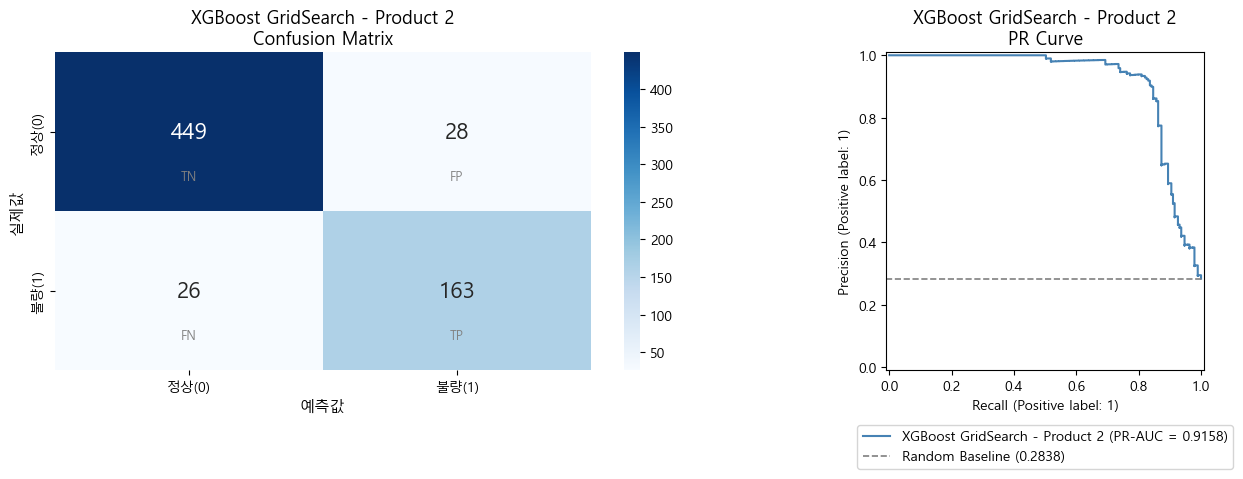

In [19]:
# 5. XGBoost GridSearch 성능 평가
evaluate_model(grid_xgb.best_estimator_, X_test, y_test, "XGBoost GridSearch - Product 2")

--- 

### 5.1 LightGBM

In [20]:
# LightGBM 모델
lgb_model = LGBMClassifier(
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    random_state=42,
)

In [21]:
# LightGBM GridSearch 실행 전 성능
print("===== LightGBM GridSearch 전 성능 =====")

lgb_model.fit(X_train, y_train)

y_pred_base_lgb = lgb_model.predict(X_test)
y_prob_base_lgb = lgb_model.predict_proba(X_test)[:,1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_base_lgb))

print("Classification Report")
print(classification_report(y_test, y_pred_base_lgb))

pr_auc_lgb_base = average_precision_score(y_test, y_prob_base_lgb)
print("PR-AUC:", pr_auc_lgb_base)

===== LightGBM GridSearch 전 성능 =====
[LightGBM] [Info] Number of positive: 757, number of negative: 1905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 2662, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.284373 -> initscore=-0.922874
[LightGBM] [Info] Start training from score -0.922874
Confusion Matrix
[[402  75]
 [ 27 162]]
Classification Report
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       477
           1       0.68      0.86      0.76       189

    accuracy                           0.85       666
   macro avg       0.81      0.85      0.82       666
weighted avg       0.87      0.85      0.85       666

PR-AUC: 0.81223439206


  LightGBM 기초 모델 - Product 2

PR-AUC: 0.8122   (Random Baseline: 0.2838)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.94      0.84      0.89       477
       불량(1)       0.68      0.86      0.76       189

    accuracy                           0.85       666
   macro avg       0.81      0.85      0.82       666
weighted avg       0.87      0.85      0.85       666



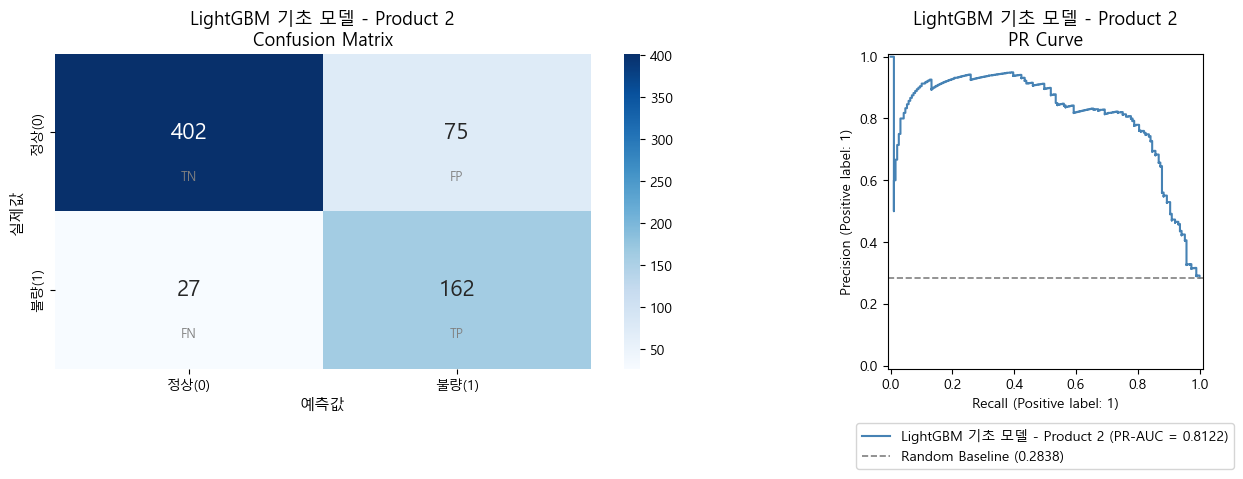

In [22]:
# 1. LightGBM 기초 성능 평가
evaluate_model(lgb_model,  X_test, y_test, "LightGBM 기초 모델 - Product 2")

#### 5.2 LightGBM - 개선
- GridSearch 최적의 파라미터로 성능 개선

In [23]:
# LightGBM GridSearch
param_grid_lgb = {
    "n_estimators"  : [100,300,500],
    "num_leaves"    : [31,63],
    "max_depth"     : [3,5,7],
    "learning_rate" : [0.05,0.1],
    "subsample"     : [0.8,1.0], # 전체(1.0) 데이터 중 0.8만 사용 (과적합 방지)
    "min_child_samples": [10, 20, 30] # XGBoost의 min_child_weight와 유사하지만 샘플 수 단위
}

In [24]:
grid_lgb = GridSearchCV(
    estimator=LGBMClassifier(
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=-1, # 모델 1개 학습 시 병렬 처리
        verbose=-1 # LightGBM 자체 로그 출력x
    ),
    param_grid=param_grid_lgb, # 탐색할 파라미터 후보
    scoring="average_precision", # 최적화
    cv=cv,
    n_jobs=-1,
    verbose=0, 
    refit=True 
)

grid_lgb.fit(X_train, y_train)

# LightGBM 결과
print("파라미터:", grid_lgb.best_params_)
print("PR-AUC:", grid_lgb.best_score_)

파라미터: {'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 500, 'num_leaves': 63, 'subsample': 0.8}
PR-AUC: 0.807791480148832


In [25]:
# LightGBM Test 평가
best_lgb = grid_lgb.best_estimator_

y_pred_lgb = best_lgb.predict(X_test)
y_prob_lgb = best_lgb.predict_proba(X_test)[:,1]

# LightGBM - Confusion Matrix
print(confusion_matrix(y_test, y_pred_lgb))

# LightGBM - Classification Report
print(classification_report(y_test, y_pred_lgb))

# LightGBM - PR-AUC
pr_auc_lgb = average_precision_score(y_test, y_prob_lgb)
print("PR-AUC:", pr_auc_lgb)

[[442  35]
 [ 26 163]]
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       477
           1       0.82      0.86      0.84       189

    accuracy                           0.91       666
   macro avg       0.88      0.89      0.89       666
weighted avg       0.91      0.91      0.91       666

PR-AUC: 0.9199419687381815



  LightGBM GridSearch - Product 2

PR-AUC: 0.9199   (Random Baseline: 0.2838)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.94      0.93      0.94       477
       불량(1)       0.82      0.86      0.84       189

    accuracy                           0.91       666
   macro avg       0.88      0.89      0.89       666
weighted avg       0.91      0.91      0.91       666



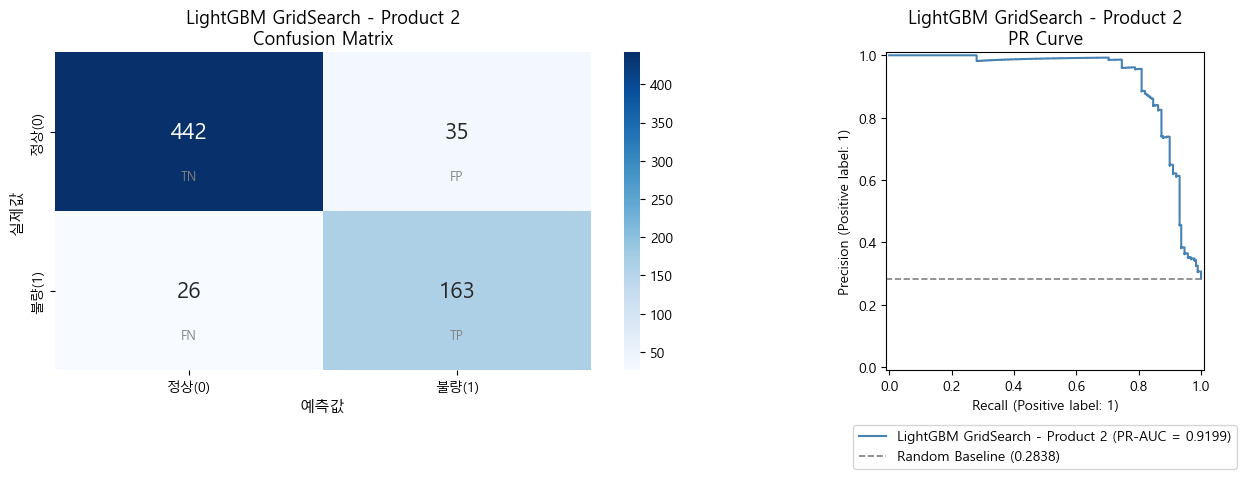

In [26]:
# 5. Light GridSearch 성능 평가
evaluate_model(grid_lgb.best_estimator_, X_test, y_test, "LightGBM GridSearch - Product 2")

---

### 6. 모델 성능 정리

In [212]:
# 모델 성능 정리
# classification_report를 dict 형태로 저장
report_xgb_base = classification_report(y_test, y_pred_base, output_dict=True)
report_lgb_base = classification_report(y_test, y_pred_base_lgb, output_dict=True)

report_xgb_grid = classification_report(y_test, y_pred_xgb, output_dict=True)
report_lgb_grid = classification_report(y_test, y_pred_lgb, output_dict=True)

# 변수 이름 통일
pr_auc_xgb_base = pr_auc_base
pr_auc_xgb_grid = pr_auc_xgb
pr_auc_lgb_grid = pr_auc_lgb

results = pd.DataFrame({
    "지표": ["PR-AUC", "불량 Precision", "불량 Recall", "불량 F1-Score"],
    
    "XGBoost Base": [
        pr_auc_xgb_base,
        report_xgb_base["1"]["precision"],
        report_xgb_base["1"]["recall"],
        report_xgb_base["1"]["f1-score"]
    ],
    
    "LightGBM Base": [
        pr_auc_lgb_base,
        report_lgb_base["1"]["precision"],
        report_lgb_base["1"]["recall"],
        report_lgb_base["1"]["f1-score"]
    ],
    
    "XGBoost Grid": [
        pr_auc_xgb_grid,
        report_xgb_grid["1"]["precision"],
        report_xgb_grid["1"]["recall"],
        report_xgb_grid["1"]["f1-score"]
    ],
    
    "LightGBM Grid": [
        pr_auc_lgb_grid,
        report_lgb_grid["1"]["precision"],
        report_lgb_grid["1"]["recall"],
        report_lgb_grid["1"]["f1-score"]
    ]
})

# 소수점 정리
results.iloc[:,1:] = results.iloc[:,1:].astype(float).round(4)

results

,지표,XGBoost Base,LightGBM Base,XGBoost Grid,LightGBM Grid
0,PR-AUC,0.7947,0.8122,0.9158,0.9199
1,불량 Precision,0.6360,0.6835,0.8534,0.8232
2,불량 Recall,0.8413,0.8571,0.8624,0.8624
3,불량 F1-Score,0.7244,0.7606,0.8579,0.8424


#### 평가

- 하이퍼파라미터 튜닝 후 PR-AUC XGB는 약 0.79에서 0.91 수준으로 향상, LightGBM는 0.81에서 0.91 수준으로 향상
- Precision이 크게 증가하여 불량으로 잘못 판단하는 비율이 감소
- Recall이 약 0.86 수준으로 유지되어 실제 불량의 대부분을 탐지

=> 그래서 PR-AUC 기준에서 가장 높은 성능(0.9199)을 보인 LightGBM Grid 모델을 최종 모델로 선정


---

### 7. SHAP 분석

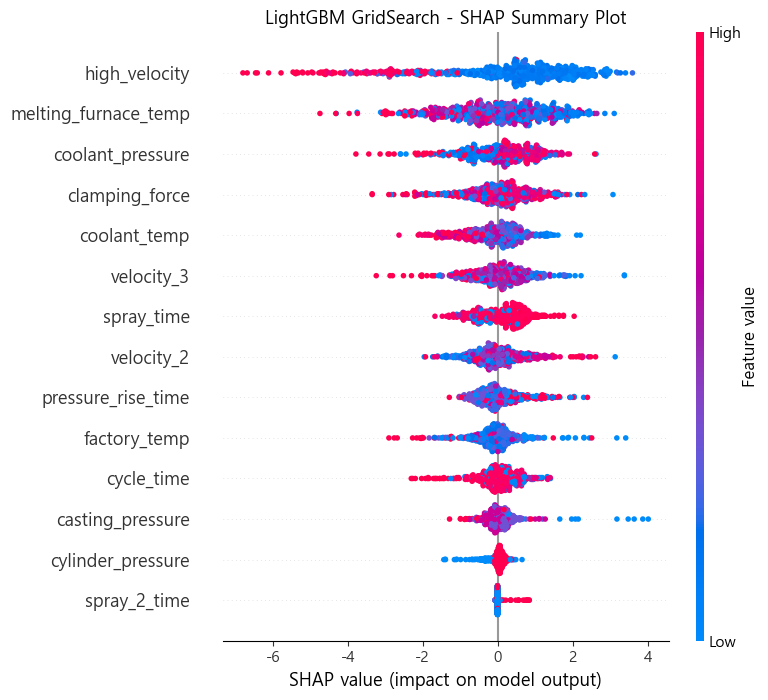

In [213]:
# ─────────────────────────────────────────────────────────────
# 3.8 SHAP 분석
#
# 목적 : 모델이 왜 이 샘플을 불량이라 예측했는지
#        각 피쳐의 기여도를 수치로 확인
# 대상 : XGBoost GridSearch 모델 (PR-AUC 기준 최고 성능)
# ─────────────────────────────────────────────────────────────

# 1. SHAP Explainer 생성
# TreeExplainer : XGBoost / LightGBM 같은 트리 기반 모델 전용 SHAP 계산기
explainer = shap.TreeExplainer(best_lgb)

# 2. SHAP 값 계산
# 각 샘플의 각 피쳐가 예측에 얼마나 기여했는지 수치로 계산
shap_values = explainer.shap_values(X_test)

# 3. SHAP Summary Plot (Beeswarm)
# - 피쳐 값이 높을 때(빨간색) / 낮을 때(파란색) 불량 확률에 어떤 영향을 주는지 표시
# - 오른쪽(+) : 불량 확률 높임 / 왼쪽(-) : 불량 확률 낮춤
# - 위에 있을수록 예측에 영향을 많이 준 피쳐
plt.figure(facecolor='none')
shap.summary_plot(
    shap_values, X_test,
    show=False
)
plt.title("LightGBM GridSearch - SHAP Summary Plot", fontsize=13)
plt.tight_layout()
plt.show()

#### SHAP 분석

1. 상위 5개 분석 (high_velocity, melting_furnace_temp, coolant_pressure, clamping_force)
- high_velocity
  - 가장 영향력이 큰 변수 <br>
  - high_velocity가 낮으면 불량 증가 (느린 속도 = 불량 증가)
- melting_furnace_temp <br>
  - melting_furnace_temp가 낮으면 불량 증가 (저온 = 불량 증가)
- coolant_pressure <br>
  - coolant_pressure가 높으면 불량 증가 (냉각 고압력 = 불량 증가)
- clamping_force <br>
  - clamping_force가 높으면 불량 증가 (과한 클램핑 = 불량 증가)
- coolant_temp <br>
  - coolant_temp가 낮으면 불량 증가 (냉각 온도 낮음 = 불량 증가) <br><br><br>

prod1과 prod2의 상위 5개 공통으로 들어가 있는 변수 <br>
high_velocity
- prod2 high_velocity는 피쳐 값이 낮으면 불량 확률이 증가 
- prod1 high_velocity는 가운데 몰려있음 => 정상으로 영향이 없다

### 모델 저장

In [214]:
# 최적 모델 가져오기
best_xgb = grid_xgb.best_estimator_
best_lgb = grid_lgb.best_estimator_

# 저장 폴더 생성 (없으면 자동 생성)
os.makedirs('../models', exist_ok=True)

# XGBoost 기초 모델
joblib.dump(xgb_model, '../models/XGBoost_기초_모델.pkl')

# XGBoost 개선 모델 (GridSearch)
joblib.dump(best_xgb, '../models/XGBoost_개선_모델.pkl')

# LightGBM 기초 모델
joblib.dump(lgb_model, '../models/LightGBM_기초_모델.pkl')

# LightGBM 개선 모델 (GridSearch)
joblib.dump(best_lgb, '../models/LightGBM_개선_모델.pkl')

['../models/LightGBM_개선_모델.pkl']